<a href="https://colab.research.google.com/github/nnm23is101-afk/deep-learrning-tasks/blob/main/dl_task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import time

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64)

100%|██████████| 170M/170M [00:01<00:00, 85.8MB/s]


In [ ]:
#Simple CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,3,padding=1)
        self.conv2 = nn.Conv2d(32,64,3,padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(64*8*8,256)
        self.fc2 = nn.Linear(256,10)
        self.dropout = nn.Dropout(0.3)

    def forward(self,x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0),-1)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)

In [ ]:
#Train Function
def train_model(model, loader, epochs=3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        total_loss = 0
        for images, labels in loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {total_loss:.3f}")

In [ ]:
#Test Accuracy
def test_model(model, loader):
    preds, labels_list = [], []
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, predicted = torch.max(outputs,1)
            preds.extend(predicted.numpy())
            labels_list.extend(labels.numpy())
    acc = accuracy_score(labels_list, preds)
    print("Accuracy:", acc)

In [ ]:
#Run Simple CNN
cnn = SimpleCNN()
start = time.time()
train_model(cnn, trainloader)
test_model(cnn, testloader)
print("Time:", time.time()-start)

Epoch 1, Loss: 1072.659
Epoch 2, Loss: 773.972
Epoch 3, Loss: 657.335
Accuracy: 0.6873
Time: 301.85458493232727


In [ ]:
#Transfer Learning
from torchvision.models import resnet18, ResNet18_Weights

resnet = resnet18(weights=ResNet18_Weights.DEFAULT)
resnet.fc = nn.Linear(resnet.fc.in_features,10)

start = time.time()
train_model(resnet, trainloader)
test_model(resnet, testloader)
print("Time:", time.time()-start)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 108MB/s]


Epoch 1, Loss: 757.500
Epoch 2, Loss: 513.277
Epoch 3, Loss: 410.250
Accuracy: 0.797
Time: 2133.4252636432648


In [ ]:
#PART B — RNN (IMDB SIMPLIFIED)
#Fake small dataset (fast run)

vocab_size = 5000
seq_len = 100

X = torch.randint(0, vocab_size, (1000, seq_len))
y = torch.randint(0, 2, (1000,1)).float()

In [ ]:
#RNN / LSTM / GRU Model
class RNNModel(nn.Module):
    def __init__(self, rnn_type="RNN"):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 64)

        if rnn_type == "LSTM":
            self.rnn = nn.LSTM(64, 64, batch_first=True)
        elif rnn_type == "GRU":
            self.rnn = nn.GRU(64, 64, batch_first=True)
        else:
            self.rnn = nn.RNN(64, 64, batch_first=True)

        self.fc = nn.Linear(64,1)

    def forward(self,x):
        x = self.embedding(x)
        _, h = self.rnn(x)
        if isinstance(h, tuple): h = h[0]
        return torch.sigmoid(self.fc(h.squeeze(0)))

In [ ]:
#Train RNN Models
def train_rnn(model):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(3):
        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        print(f"Loss: {loss.item():.4f}")

In [ ]:
#Run Models
for name in ["RNN","LSTM","GRU"]:
    print("\n", name)
    model = RNNModel(name)
    train_rnn(model)


 RNN
Loss: 0.7073
Loss: 0.7005
Loss: 0.6941

 LSTM
Loss: 0.6955
Loss: 0.6932
Loss: 0.6910

 GRU
Loss: 0.7043
Loss: 0.7002
Loss: 0.6963


In [ ]:
# PART C — GAN (Fashion-MNIST)

#Load Dataset
dataset = torchvision.datasets.FashionMNIST(root='./data',
                                            download=True,
                                            transform=transforms.ToTensor())

loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 344kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.24MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.3MB/s]


In [ ]:
#Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100,256),
            nn.ReLU(),
            nn.Linear(256,784),
            nn.Tanh()
        )
    def forward(self,x):
        return self.net(x).view(-1,1,28,28)

In [ ]:
#Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784,256),
            nn.LeakyReLU(0.2),
            nn.Linear(256,1),
            nn.Sigmoid()
        )
    def forward(self,x):
        return self.net(x)

In [ ]:
#Train GAN
G = Generator()
D = Discriminator()

criterion = nn.BCELoss()
g_opt = optim.Adam(G.parameters(), lr=0.0002)
d_opt = optim.Adam(D.parameters(), lr=0.0002)

for epoch in range(3):
    for real,_ in loader:
        batch = real.size(0)

        real_labels = torch.ones(batch,1)
        fake_labels = torch.zeros(batch,1)

        # Train D
        d_opt.zero_grad()
        real_out = D(real)
        loss_real = criterion(real_out, real_labels)

        z = torch.randn(batch,100)
        fake = G(z)
        fake_out = D(fake.detach())
        loss_fake = criterion(fake_out, fake_labels)

        d_loss = loss_real + loss_fake
        d_loss.backward()
        d_opt.step()

        # Train G
        g_opt.zero_grad()
        fake_out = D(fake)
        g_loss = criterion(fake_out, real_labels)
        g_loss.backward()
        g_opt.step()

    print(f"Epoch {epoch+1}, D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

Epoch 1, D Loss: 0.7980, G Loss: 1.1260
Epoch 2, D Loss: 1.0665, G Loss: 0.8811
Epoch 3, D Loss: 1.0402, G Loss: 1.0719


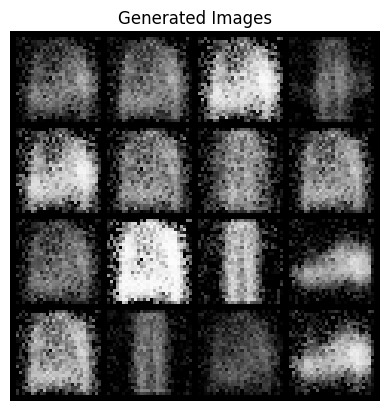

In [ ]:
#Show Generated Images
z = torch.randn(16,100)
fake_imgs = G(z).detach()

grid = torchvision.utils.make_grid(fake_imgs, nrow=4)
plt.imshow(grid.permute(1,2,0))
plt.title("Generated Images")
plt.axis("off")
plt.show()